In [1]:
import numpy as np
from dataclasses import dataclass
from typing import Tuple, Optional

# === CAMERA SPECS ===
# Sony a7R III camera
sony_sensor_width = 35.9  # mm
sony_sensor_height = 24.0  # mm

# === HELIOS LENS DATA ===
# Helios 44-2 58mm/f2 lens
helios_measured_aperture = [3.0, 8.0, 12.0, 15.0, 17.2, 19.0, 20.0]  # mm
focal_length = 58.0  # mm
helios_aperture_stops = [2.0, 2.8, 4.0, 5.6, 8.0, 11.0, 16.0]  # f-stops [0; 6]

# === BIOTAR PATENT DATA ===
# curvature radii (patent units)
no_curv = 0.0
biotar_r1_p = 83.6
biotar_r2_p = 321.0
biotar_r3_p = 44.8
biotar_r4_p = -1150.0
biotar_r5_p = 28.3
biotar_r6_p = -38.5
biotar_r7_p = 50.5
biotar_r8_p = -53.2
biotar_r9_p = 106.0
biotar_r10_p = -120.0

# lens thicknesses (patent units)
biotar_d1_p = 10.75
biotar_d2_p = 15.55
biotar_d3_p = 5.05
biotar_d4_p = 5.05
biotar_d5_p = 21.22
biotar_d6_p = 13.9

# separations (patent units)
biotar_l1_p = 1.65
biotar_l2_p = 18.9
biotar_l3_p = 0.97

# refractive indices
n_air = 1.0
biotar_n1 = 1.64238
biotar_n2 = 1.62306
biotar_n3 = 1.57566
biotar_n4 = 1.67270
biotar_n5 = 1.64238
biotar_n6 = 1.64238

# Abbe numbers
v_air = 89.30
biotar_v1 = 48.0
biotar_v2 = 56.9
biotar_v3 = 41.2
biotar_v4 = 32.2
biotar_v5 = 48.0
biotar_v6 = 48.0

# measured (pixel)
biotar_a1_px = 455  # diameter
biotar_a2_px = 406  # diameter
biotar_a3_px = 270  # diameter
biotar_a4_px = 362  # diameter

biotar_l2_1 = 73
biotar_l2_2 = 46

# measured (pixel) for pixel to mm conversion
biotar_d1_px = 71
biotar_d2_px = 100
biotar_d3_px = 30
biotar_d4_px = 30
biotar_d5_px = 134
biotar_d6_px = 86

# === CONSTRUCTION OF USABLE LENS DATA ===

# conversions
patent_to_mm = focal_length / 100.0
pixel_to_patent = (
    biotar_d1_p / biotar_d1_px +
    biotar_d2_p / biotar_d2_px +
    biotar_d3_p / biotar_d3_px +
    biotar_d4_p / biotar_d4_px +
    biotar_d5_p / biotar_d5_px +
    biotar_d6_p / biotar_d6_px
) / 6.0  # patent units per pixel, averaged

# curvature radii (mm)
r1_curv = biotar_r1_p * patent_to_mm
r2_curv = biotar_r2_p * patent_to_mm
r3_curv = biotar_r3_p * patent_to_mm
r4_curv = biotar_r4_p * patent_to_mm
r5_curv = biotar_r5_p * patent_to_mm
r6_curv = biotar_r6_p * patent_to_mm
r7_curv = biotar_r7_p * patent_to_mm
r8_curv = biotar_r8_p * patent_to_mm
r9_curv = biotar_r9_p * patent_to_mm
r10_curv = biotar_r10_p * patent_to_mm

# lens size radii (mm)
a1 = biotar_a1_px * pixel_to_patent * patent_to_mm * 0.5
a2 = biotar_a2_px * pixel_to_patent * patent_to_mm * 0.5
a3 = biotar_a3_px * pixel_to_patent * patent_to_mm * 0.5
a4 = biotar_a4_px * pixel_to_patent * patent_to_mm * 0.5

# lens thicknesses (mm)
d1 = biotar_d1_p * patent_to_mm
d2 = biotar_d2_p * patent_to_mm
d3 = biotar_d3_p * patent_to_mm
d4 = biotar_d4_p * patent_to_mm
d5 = biotar_d5_p * patent_to_mm
d6 = biotar_d6_p * patent_to_mm

# lens separations (mm)
l1 = biotar_l1_p * patent_to_mm
l2 = biotar_l2_p * patent_to_mm
l3 = biotar_l3_p * patent_to_mm

print(f"Lens data loaded. Focal length: {focal_length}mm")

Lens data loaded. Focal length: 58.0mm


In [2]:
@dataclass
class Ray:
    """Ray representation with origin and direction."""
    origin: np.ndarray  # float3
    direction: np.ndarray  # float3

@dataclass
class LensElement:
    """Lens element structure."""
    curvature_radius: float  # positive = convex toward object, negative = concave, 0 = flat
    thickness: float  # distance to next element
    n: float  # refractive index
    v: float  # Abbe number
    aperture_radius: float  # radius of lens element
    apply_opening_texture: bool  # if texture determines shape

def create_lens_element(curvature_radius: float, thickness: float, n: float, v: float, 
                        aperture_radius: float, apply_opening_texture: bool) -> LensElement:
    return LensElement(curvature_radius, thickness, n, v, aperture_radius, apply_opening_texture)

def get_lens_elements(aperture_stop: int = 0, focus_distance: float = 1.0) -> list:
    """
    Create lens elements array with given aperture stop and focus distance.
    
    Args:
        aperture_stop: Index into helios_aperture_stops (0-6)
        focus_distance: Focus distance parameter
    
    Returns:
        List of LensElement objects
    """
    aperture = helios_measured_aperture[aperture_stop] * (a3 / (helios_measured_aperture[6] * 0.5)) * 0.5
    d_to_film = 335.598 / (focus_distance + 15.4) + 37.887  # mm, empirically fitted curve
    
    lens_elements = [
        # Zeiss BIOTAR 58mm lens with Helios 44-2 aperture shape
        #                   curvature    separation    n           v           opening     texture
        create_lens_element(r1_curv,     d1,           biotar_n1,  biotar_v1,  a1,         False),
        create_lens_element(r2_curv,     l1,           n_air,      v_air,      a1,         False),
        create_lens_element(r3_curv,     d2,           biotar_n2,  biotar_v2,  a2,         False),
        create_lens_element(r4_curv,     d3,           biotar_n3,  biotar_v3,  a2,         False),
        create_lens_element(r5_curv,     l2 / 2,       n_air,      v_air,      a4,         False),
        create_lens_element(no_curv,     l2 / 2,       n_air,      v_air,      aperture,   True),
        create_lens_element(r6_curv,     d4,           biotar_n4,  biotar_v4,  a3,         False),
        create_lens_element(r7_curv,     d5,           biotar_n5,  biotar_v5,  a4,         False),
        create_lens_element(r8_curv,     l3,           n_air,      v_air,      a4,         False),
        create_lens_element(r9_curv,     d6,           biotar_n6,  biotar_v6,  a4,         False),
        create_lens_element(r10_curv,    d_to_film,    n_air,      v_air,      a4,         False),
    ]
    return lens_elements

print("Ray and LensElement classes defined")

Ray and LensElement classes defined


In [3]:
def sphere_ray_intersect(ray_origin: np.ndarray, ray_dir: np.ndarray, 
                         radius: float) -> Tuple[bool, np.ndarray]:
    """
    Ray-sphere intersection for a sphere at the origin.
    
    Args:
        ray_origin: Ray origin (3D vector)
        ray_dir: Ray direction (3D vector)
        radius: Sphere radius
    
    Returns:
        Tuple of (hit, intersections) where intersections is [t0, t1] with t0 <= t1
    """
    intersections = np.array([0.0, 0.0])
    
    a = np.dot(ray_dir, ray_dir)
    # avoid divide by zero for degenerate rays
    if a <= 1e-12:
        return False, intersections
    
    b = np.dot(ray_origin, ray_dir)
    c = np.dot(ray_origin, ray_origin) - radius * radius
    
    discr = b * b - a * c
    if discr < 0.0:
        return False, intersections
    
    sqrt_d = np.sqrt(discr)
    t0 = (-b - sqrt_d) / a
    t1 = (-b + sqrt_d) / a
    
    if t0 > t1:
        t0, t1 = t1, t0
    
    intersections = np.array([t0, t1])
    return True, intersections


def intersect(radius: float, center: float, ray: Ray) -> Tuple[bool, float, np.ndarray]:
    """
    Intersect ray with lens surface (sphere centered at (0, 0, center)).
    
    Args:
        radius: Curvature radius of lens surface
        center: Z-coordinate of sphere center
        ray: Input ray
    
    Returns:
        Tuple of (hit, t, normal)
    """
    t = 0.0
    normal = np.array([0.0, 0.0, 0.0])
    
    # Shift ray origin to sphere-local coordinates
    local_origin = ray.origin - np.array([0.0, 0.0, center])
    
    hit, intersections = sphere_ray_intersect(local_origin, ray.direction, radius)
    if not hit:
        return False, t, normal
    
    # Choose which intersection to use based on ray direction and radius sign
    use_closer_t = (ray.direction[2] > 0) ^ (radius < 0)
    t = min(intersections[1], intersections[0]) if use_closer_t else max(intersections[1], intersections[0])
    
    hit_point = ray.origin + t * ray.direction
    normal = (hit_point - np.array([0.0, 0.0, center]))
    normal = normal / np.linalg.norm(normal)
    
    # Flip normal if using second intersection
    normal *= 1.0 if use_closer_t else -1.0
    
    return True, t, normal


def get_eta_for_wavelength(n_D: float, v_D: float, wavelength: float) -> float:
    """
    Calculate wavelength-dependent refractive index using Cauchy's equation.
    
    Args:
        n_D: Refractive index at sodium D line
        v_D: Abbe number
        wavelength: Wavelength in nm
    
    Returns:
        Refractive index at given wavelength
    """
    # Fraunhofer lines wavelengths (nm)
    lambda_F = 486.1327  # Fraunhofer F
    lambda_D = 589.2938  # Fraunhofer D
    lambda_C = 656.2725  # Fraunhofer C
    
    B = ((n_D - 1.0) / v_D) / ((1.0 / (lambda_F * lambda_F)) - (1.0 / (lambda_C * lambda_C)))
    A = n_D - B / (lambda_D * lambda_D)
    eta = A + B / (wavelength * wavelength)
    
    return eta


def refract(incident: np.ndarray, normal: np.ndarray, eta: float) -> Optional[np.ndarray]:
    """
    Compute refracted ray direction using Snell's law.
    
    Args:
        incident: Incident ray direction (normalized)
        normal: Surface normal (normalized)
        eta: Ratio of refractive indices (n_incident / n_transmitted)
    
    Returns:
        Refracted direction or None if total internal reflection
    """
    cos_i = -np.dot(normal, incident)
    sin2_t = eta * eta * (1.0 - cos_i * cos_i)
    
    # Total internal reflection check
    if sin2_t > 1.0:
        return None
    
    cos_t = np.sqrt(1.0 - sin2_t)
    refracted = eta * incident + (eta * cos_i - cos_t) * normal
    
    return refracted / np.linalg.norm(refracted)


print("Core ray tracing functions defined")

Core ray tracing functions defined


In [4]:
def trace_lenses_from_film(ray: Ray, wavelength: float, 
                           lens_elements: list,
                           sample_aperture_mask=None) -> Tuple[bool, Optional[Ray]]:
    """
    Trace ray from film through lens elements toward the scene.
    
    Args:
        ray: Input ray starting at film plane
        wavelength: Wavelength in nm (0 for no dispersion)
        lens_elements: List of LensElement objects
        sample_aperture_mask: Optional function(uv) -> float for aperture mask sampling
    
    Returns:
        Tuple of (success, output_ray)
    """
    z = 0.0  # start at the film, z = 0
    element_count = len(lens_elements)
    
    # Create a copy of ray to modify
    current_ray = Ray(
        origin=ray.origin.copy(),
        direction=ray.direction.copy()
    )
    
    for i in range(element_count - 1, -1, -1):
        curvature_radius = lens_elements[i].curvature_radius
        thickness = lens_elements[i].thickness
        nI_D = lens_elements[i].n
        nT_D = lens_elements[i - 1].n if i > 0 else n_air
        vI_D = lens_elements[i].v
        vT_D = lens_elements[i - 1].v if i > 0 else v_air
        aperture_radius = lens_elements[i].aperture_radius
        use_opening_texture = lens_elements[i].apply_opening_texture
        
        # Choose eta (skip dispersion if wavelength == 0)
        if wavelength == 0.0:
            etaI = nI_D
            etaT = nT_D
        else:
            etaI = get_eta_for_wavelength(nI_D, vI_D, wavelength)
            etaT = get_eta_for_wavelength(nT_D, vT_D, wavelength)
        
        z -= thickness
        t = 0.0
        normal = np.array([0.0, 0.0, 0.0])
        
        is_stop = (curvature_radius == 0.0)
        if is_stop:
            if current_ray.direction[2] >= 0.0:
                return False, None
            t = (z - current_ray.origin[2]) / current_ray.direction[2]
        else:
            center = z + curvature_radius
            hit, t, normal = intersect(curvature_radius, center, current_ray)
            if not hit:
                return False, None
        
        hit_point = current_ray.origin + t * current_ray.direction
        
        # Aperture mask test
        if use_opening_texture:
            # Normalize hit to aperture space
            p = hit_point[:2] / aperture_radius
            mask_uv = p * 0.5 + 0.5  # [-1,1] -> [0,1]
            
            out_of_bounds = (mask_uv[0] < 0.0 or mask_uv[0] > 1.0 or 
                            mask_uv[1] < 0.0 or mask_uv[1] > 1.0)
            if out_of_bounds:
                return False, None
            
            if sample_aperture_mask is not None:
                mask_value = sample_aperture_mask(mask_uv)
                if mask_value < 0.5:
                    return False, None
        else:
            # Default circular aperture test
            r2 = hit_point[0] * hit_point[0] + hit_point[1] * hit_point[1]
            if r2 > (aperture_radius * aperture_radius):
                return False, None
        
        current_ray.origin = hit_point.copy()
        
        if not is_stop:
            eta = etaI / (etaT if etaT > 0.0 else 1.0)
            refract_dir = refract(current_ray.direction, normal, eta)
            
            # refract returns None on total internal reflection
            if refract_dir is None:
                return False, None
            
            current_ray.direction = refract_dir
    
    return True, current_ray


print("Lens tracing function defined")

Lens tracing function defined


In [5]:
def apply_realistic_lens_simulation(
    screen_pos: np.ndarray,
    screen_dims: Tuple[int, int],
    wavelength: float,
    lens_elements: list,
    rng: np.random.Generator,
    sample_aperture_mask=None
) -> Tuple[float, Optional[Ray]]:
    """
    Apply realistic lens simulation for a given screen position.
    
    Args:
        screen_pos: Normalized screen position in [-1, 1]
        screen_dims: Screen dimensions (width, height)
        wavelength: Wavelength in nm (0 for no dispersion)
        lens_elements: List of LensElement objects
        rng: Random number generator
        sample_aperture_mask: Optional function for aperture mask sampling
    
    Returns:
        Tuple of (PDF, ray) where ray is None if tracing failed
    """
    # Map normalized screen position to film plane coordinates in mm
    aspect = screen_dims[0] / screen_dims[1]
    sensor_height = min(sony_sensor_height, sony_sensor_width / aspect)
    sensor_width = sensor_height * aspect
    
    film_x = -screen_pos[0] * (sensor_width * 0.5)
    film_y = -screen_pos[1] * (sensor_height * 0.5)
    
    # Sample random point on closest lens element using polar coordinates
    theta = rng.uniform(0, 2 * np.pi)
    r = np.sqrt(rng.uniform(0, 1))
    aperture_offset = np.array([np.cos(theta), np.sin(theta)]) * r
    aperture_offset *= a4  # scale to aperture radius
    
    # Get distance to film from lens elements (last element's thickness)
    d_to_film = lens_elements[-1].thickness
    
    # Construct film-space ray with sampled aperture offset
    film_ray = Ray(
        origin=np.array([film_x, film_y, 0.0]),
        direction=np.zeros(3)
    )
    target = np.array([aperture_offset[0], aperture_offset[1], -d_to_film])
    film_ray.direction = target - film_ray.origin
    film_ray.direction = film_ray.direction / np.linalg.norm(film_ray.direction)
    
    # Trace ray through lens elements
    success, refracted = trace_lenses_from_film(film_ray, wavelength, lens_elements, sample_aperture_mask)
    
    if success and refracted is not None:
        return 1.0, refracted
    
    return 0.0, None


def trace_realistic_monochrome(
    screen_pos: np.ndarray,
    screen_dims: Tuple[int, int],
    lens_elements: list,
    rng: np.random.Generator,
    sample_aperture_mask=None
) -> Tuple[float, Optional[Ray]]:
    """
    Realistic lens trace, single wavelength (no chromatic splitting).
    
    Args:
        screen_pos: Normalized screen position in [-1, 1]
        screen_dims: Screen dimensions (width, height)
        lens_elements: List of LensElement objects
        rng: Random number generator
        sample_aperture_mask: Optional aperture mask function
    
    Returns:
        Tuple of (PDF, ray)
    """
    return apply_realistic_lens_simulation(
        screen_pos, screen_dims, 0.0, lens_elements, rng, sample_aperture_mask
    )


def trace_realistic_chromatic(
    screen_pos: np.ndarray,
    screen_dims: Tuple[int, int],
    lens_elements: list,
    rng: np.random.Generator,
    sample_aperture_mask=None
) -> list:
    """
    Realistic lens with RGB chromatic aberration splitting.
    
    Args:
        screen_pos: Normalized screen position in [-1, 1]
        screen_dims: Screen dimensions (width, height)
        lens_elements: List of LensElement objects
        rng: Random number generator
        sample_aperture_mask: Optional aperture mask function
    
    Returns:
        List of (PDF, ray) tuples for [R, G, B] wavelengths
    """
    # Representative wavelengths for RGB (nm)
    wl_r = 625.0
    wl_g = 510.0
    wl_b = 440.0
    wavelengths = [wl_r, wl_g, wl_b]
    
    results = []
    for wl in wavelengths:
        pdf, ray = apply_realistic_lens_simulation(
            screen_pos, screen_dims, wl, lens_elements, rng, sample_aperture_mask
        )
        results.append((pdf, ray))
    
    return results


print("High-level lens simulation functions defined")

High-level lens simulation functions defined


In [6]:
# === EXAMPLE USAGE ===

# Create lens elements with default aperture stop and focus distance
aperture_stop = 0  # f/2.0
focus_distance = 1.0  # meters
lens_elements = get_lens_elements(aperture_stop, focus_distance)

# Print lens configuration
print(f"Lens configuration:")
print(f"  Aperture stop: f/{helios_aperture_stops[aperture_stop]}")
print(f"  Focus distance: {focus_distance}m")
print(f"  Number of elements: {len(lens_elements)}")
print()

# Test single ray trace
rng = np.random.default_rng(42)
screen_dims = (1920, 1080)
screen_pos = np.array([0.0, 0.0])  # center of screen

pdf, ray = trace_realistic_monochrome(screen_pos, screen_dims, lens_elements, rng)

if ray is not None:
    print(f"Monochrome trace (center):")
    print(f"  Origin: {ray.origin}")
    print(f"  Direction: {ray.direction}")
    print(f"  PDF: {pdf}")
else:
    print("Ray was blocked by lens aperture")

print()

# Test chromatic trace
chromatic_results = trace_realistic_chromatic(screen_pos, screen_dims, lens_elements, rng)
wavelength_names = ['Red (625nm)', 'Green (510nm)', 'Blue (440nm)']

print("Chromatic trace (center):")
for i, (pdf, ray) in enumerate(chromatic_results):
    if ray is not None:
        print(f"  {wavelength_names[i]}:")
        print(f"    Origin: {ray.origin}")
        print(f"    Direction: {ray.direction}")
    else:
        print(f"  {wavelength_names[i]}: blocked")

Lens configuration:
  Aperture stop: f/2.0
  Focus distance: 1.0m
  Number of elements: 11

Ray was blocked by lens aperture

Chromatic trace (center):
  Red (625nm): blocked
  Green (510nm): blocked
  Blue (440nm): blocked


In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Circle

def trace_lenses_from_film_with_path(ray: Ray, wavelength: float, 
                                      lens_elements: list,
                                      sample_aperture_mask=None) -> Tuple[bool, Optional[Ray], list]:
    """
    Trace ray from film through lens elements, recording the path.
    
    Returns:
        Tuple of (success, output_ray, path) where path is list of (x, y, z) points
    """
    z = 0.0
    element_count = len(lens_elements)
    path = [ray.origin.copy()]  # Start with initial position
    
    current_ray = Ray(
        origin=ray.origin.copy(),
        direction=ray.direction.copy()
    )
    
    for i in range(element_count - 1, -1, -1):
        curvature_radius = lens_elements[i].curvature_radius
        thickness = lens_elements[i].thickness
        nI_D = lens_elements[i].n
        nT_D = lens_elements[i - 1].n if i > 0 else n_air
        vI_D = lens_elements[i].v
        vT_D = lens_elements[i - 1].v if i > 0 else v_air
        aperture_radius = lens_elements[i].aperture_radius
        use_opening_texture = lens_elements[i].apply_opening_texture
        
        if wavelength == 0.0:
            etaI = nI_D
            etaT = nT_D
        else:
            etaI = get_eta_for_wavelength(nI_D, vI_D, wavelength)
            etaT = get_eta_for_wavelength(nT_D, vT_D, wavelength)
        
        z -= thickness
        
        is_stop = (curvature_radius == 0.0)
        if is_stop:
            if current_ray.direction[2] >= 0.0:
                return False, None, path
            t = (z - current_ray.origin[2]) / current_ray.direction[2]
        else:
            center = z + curvature_radius
            hit, t, normal = intersect(curvature_radius, center, current_ray)
            if not hit:
                return False, None, path
        
        hit_point = current_ray.origin + t * current_ray.direction
        
        if use_opening_texture:
            p = hit_point[:2] / aperture_radius
            mask_uv = p * 0.5 + 0.5
            out_of_bounds = (mask_uv[0] < 0.0 or mask_uv[0] > 1.0 or 
                            mask_uv[1] < 0.0 or mask_uv[1] > 1.0)
            if out_of_bounds:
                return False, None, path
            if sample_aperture_mask is not None:
                mask_value = sample_aperture_mask(mask_uv)
                if mask_value < 0.5:
                    return False, None, path
        else:
            r2 = hit_point[0] * hit_point[0] + hit_point[1] * hit_point[1]
            if r2 > (aperture_radius * aperture_radius):
                return False, None, path
        
        path.append(hit_point.copy())
        current_ray.origin = hit_point.copy()
        
        if not is_stop:
            eta = etaI / (etaT if etaT > 0.0 else 1.0)
            refract_dir = refract(current_ray.direction, normal, eta)
            if refract_dir is None:
                return False, None, path
            current_ray.direction = refract_dir
    
    # Extend ray beyond lens system for visualization
    exit_point = current_ray.origin + current_ray.direction * 50  # 50mm extension
    path.append(exit_point)
    
    return True, current_ray, path


def get_lens_surface_positions(lens_elements: list) -> list:
    """Get z-positions and properties of each lens surface for plotting."""
    surfaces = []
    z = 0.0
    
    for i in range(len(lens_elements) - 1, -1, -1):
        z -= lens_elements[i].thickness
        surfaces.append({
            'z': z,
            'curvature_radius': lens_elements[i].curvature_radius,
            'aperture_radius': lens_elements[i].aperture_radius,
            'n': lens_elements[i].n,
            'is_stop': lens_elements[i].curvature_radius == 0.0
        })
    
    return surfaces[::-1]  # Reverse to go from object to film


def draw_lens_elements(ax, lens_elements: list, view='xz'):
    """Draw lens element surfaces on the given axis."""
    surfaces = get_lens_surface_positions(lens_elements)
    
    for i, surf in enumerate(surfaces):
        z = surf['z']
        r = surf['aperture_radius']
        curv = surf['curvature_radius']
        
        if surf['is_stop']:
            # Draw aperture stop as vertical lines
            if view == 'xz':
                ax.plot([z, z], [r, r + 3], 'k-', linewidth=2)
                ax.plot([z, z], [-r, -r - 3], 'k-', linewidth=2)
            elif view == 'yz':
                ax.plot([z, z], [r, r + 3], 'k-', linewidth=2)
                ax.plot([z, z], [-r, -r - 3], 'k-', linewidth=2)
        elif curv != 0:
            # Draw curved lens surface
            center_z = z + curv
            # Calculate arc angles
            if abs(curv) >= r:
                half_angle = np.degrees(np.arcsin(r / abs(curv)))
            else:
                half_angle = 90
            
            if curv > 0:
                theta1 = 180 - half_angle
                theta2 = 180 + half_angle
            else:
                theta1 = -half_angle
                theta2 = half_angle
            
            # Draw the arc
            theta = np.linspace(np.radians(theta1), np.radians(theta2), 50)
            arc_z = center_z + abs(curv) * np.cos(theta)
            arc_r = abs(curv) * np.sin(theta)
            
            color = 'blue' if surf['n'] > 1.0 else 'gray'
            ax.plot(arc_z, arc_r, color=color, linewidth=1.5, alpha=0.7)


def plot_ray_paths(lens_elements: list, num_rays: int = 10, 
                   screen_positions: list = None, wavelength: float = 0.0,
                   seed: int = 42):
    """
    Plot ray paths through the lens system from multiple perspectives.
    
    Args:
        lens_elements: List of LensElement objects
        num_rays: Number of rays to trace per screen position
        screen_positions: List of (x, y) normalized screen positions
        wavelength: Wavelength in nm (0 for no dispersion)
        seed: Random seed for reproducibility
    """
    if screen_positions is None:
        screen_positions = [
            (0.0, 0.0),    # center
            (0.5, 0.0),    # right
            (-0.5, 0.0),   # left
            (0.0, 0.5),    # top
            (0.8, 0.0),    # far right
        ]
    
    rng = np.random.default_rng(seed)
    screen_dims = (1920, 1080)
    
    # Collect all ray paths
    all_paths = []
    colors = plt.cm.rainbow(np.linspace(0, 1, len(screen_positions)))
    
    for pos_idx, screen_pos in enumerate(screen_positions):
        screen_pos_arr = np.array(screen_pos)
        
        for ray_idx in range(num_rays):
            # Map screen position to film coordinates
            aspect = screen_dims[0] / screen_dims[1]
            sensor_height = min(sony_sensor_height, sony_sensor_width / aspect)
            sensor_width = sensor_height * aspect
            
            film_x = -screen_pos_arr[0] * (sensor_width * 0.5)
            film_y = -screen_pos_arr[1] * (sensor_height * 0.5)
            
            # Sample aperture
            theta = rng.uniform(0, 2 * np.pi)
            r = np.sqrt(rng.uniform(0, 1))
            aperture_offset = np.array([np.cos(theta), np.sin(theta)]) * r * a4
            
            d_to_film = lens_elements[-1].thickness
            
            film_ray = Ray(
                origin=np.array([film_x, film_y, 0.0]),
                direction=np.zeros(3)
            )
            target = np.array([aperture_offset[0], aperture_offset[1], -d_to_film])
            film_ray.direction = target - film_ray.origin
            film_ray.direction = film_ray.direction / np.linalg.norm(film_ray.direction)
            
            success, _, path = trace_lenses_from_film_with_path(
                film_ray, wavelength, lens_elements
            )
            
            if success and len(path) > 1:
                all_paths.append({
                    'path': np.array(path),
                    'color': colors[pos_idx],
                    'label': f'Screen ({screen_pos[0]:.1f}, {screen_pos[1]:.1f})'
                })
    
    # Create figure with multiple views
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Side view (Y-Z plane) - looking from the side, see height (Y) vs depth (Z)
    ax1 = axes[0, 0]
    ax1.set_title('Side View (Y-Z plane)')
    ax1.set_xlabel('Z (mm) - Optical Axis')
    ax1.set_ylabel('Y (mm) - Vertical')
    draw_lens_elements(ax1, lens_elements, view='yz')
    
    plotted_labels = set()
    for path_data in all_paths:
        path = path_data['path']
        label = path_data['label'] if path_data['label'] not in plotted_labels else None
        ax1.plot(path[:, 2], path[:, 1], color=path_data['color'], alpha=0.5, linewidth=0.8, label=label)
        if label:
            plotted_labels.add(path_data['label'])
    
    # Draw film plane
    ax1.axvline(x=0, color='brown', linestyle='--', linewidth=2, label='Film plane')
    ax1.legend(loc='upper left', fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    
    # Plot 2: Top view (X-Z plane) - looking from above, see width (X) vs depth (Z)
    ax2 = axes[0, 1]
    ax2.set_title('Top View (X-Z plane)')
    ax2.set_xlabel('Z (mm) - Optical Axis')
    ax2.set_ylabel('X (mm) - Horizontal')
    draw_lens_elements(ax2, lens_elements, view='xz')
    
    for path_data in all_paths:
        path = path_data['path']
        ax2.plot(path[:, 2], path[:, 0], color=path_data['color'], alpha=0.5, linewidth=0.8)
    
    ax2.axvline(x=0, color='brown', linestyle='--', linewidth=2)
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal')
    
    # Plot 3: Front view (X-Y plane) - looking along optical axis toward scene
    ax3 = axes[1, 0]
    ax3.set_title('Front View (X-Y plane) - Exit Pupil')
    ax3.set_xlabel('X (mm) - Horizontal')
    ax3.set_ylabel('Y (mm) - Vertical')
    
    # Draw aperture circle
    surfaces = get_lens_surface_positions(lens_elements)
    front_aperture = surfaces[0]['aperture_radius']
    circle = Circle((0, 0), front_aperture, fill=False, color='gray', linewidth=2)
    ax3.add_patch(circle)
    
    for path_data in all_paths:
        path = path_data['path']
        if len(path) > 0:
            # Plot exit point
            ax3.scatter(path[-2, 0], path[-2, 1], color=path_data['color'], alpha=0.3, s=10)
    
    ax3.set_xlim(-front_aperture * 1.2, front_aperture * 1.2)
    ax3.set_ylim(-front_aperture * 1.2, front_aperture * 1.2)
    ax3.grid(True, alpha=0.3)
    ax3.set_aspect('equal')
    
    # Plot 4: Film plane (X-Y) - ray origins (rear view, looking from behind camera)
    ax4 = axes[1, 1]
    ax4.set_title('Rear View (X-Y plane) - Film/Sensor')
    ax4.set_xlabel('X (mm) - Horizontal')
    ax4.set_ylabel('Y (mm) - Vertical')
    
    # Draw sensor outline
    aspect = screen_dims[0] / screen_dims[1]
    sensor_height = min(sony_sensor_height, sony_sensor_width / aspect)
    sensor_width = sensor_height * aspect
    rect = plt.Rectangle((-sensor_width/2, -sensor_height/2), sensor_width, sensor_height,
                         fill=False, color='brown', linewidth=2, label='Sensor')
    ax4.add_patch(rect)
    
    for path_data in all_paths:
        path = path_data['path']
        ax4.scatter(path[0, 0], path[0, 1], color=path_data['color'], alpha=0.5, s=20)
    
    ax4.set_xlim(-sensor_width * 0.7, sensor_width * 0.7)
    ax4.set_ylim(-sensor_height * 0.7, sensor_height * 0.7)
    ax4.grid(True, alpha=0.3)
    ax4.set_aspect('equal')
    ax4.legend()
    
    plt.tight_layout()
    plt.show()
    
    return fig

print("Ray path visualization functions defined")

Ray path visualization functions defined


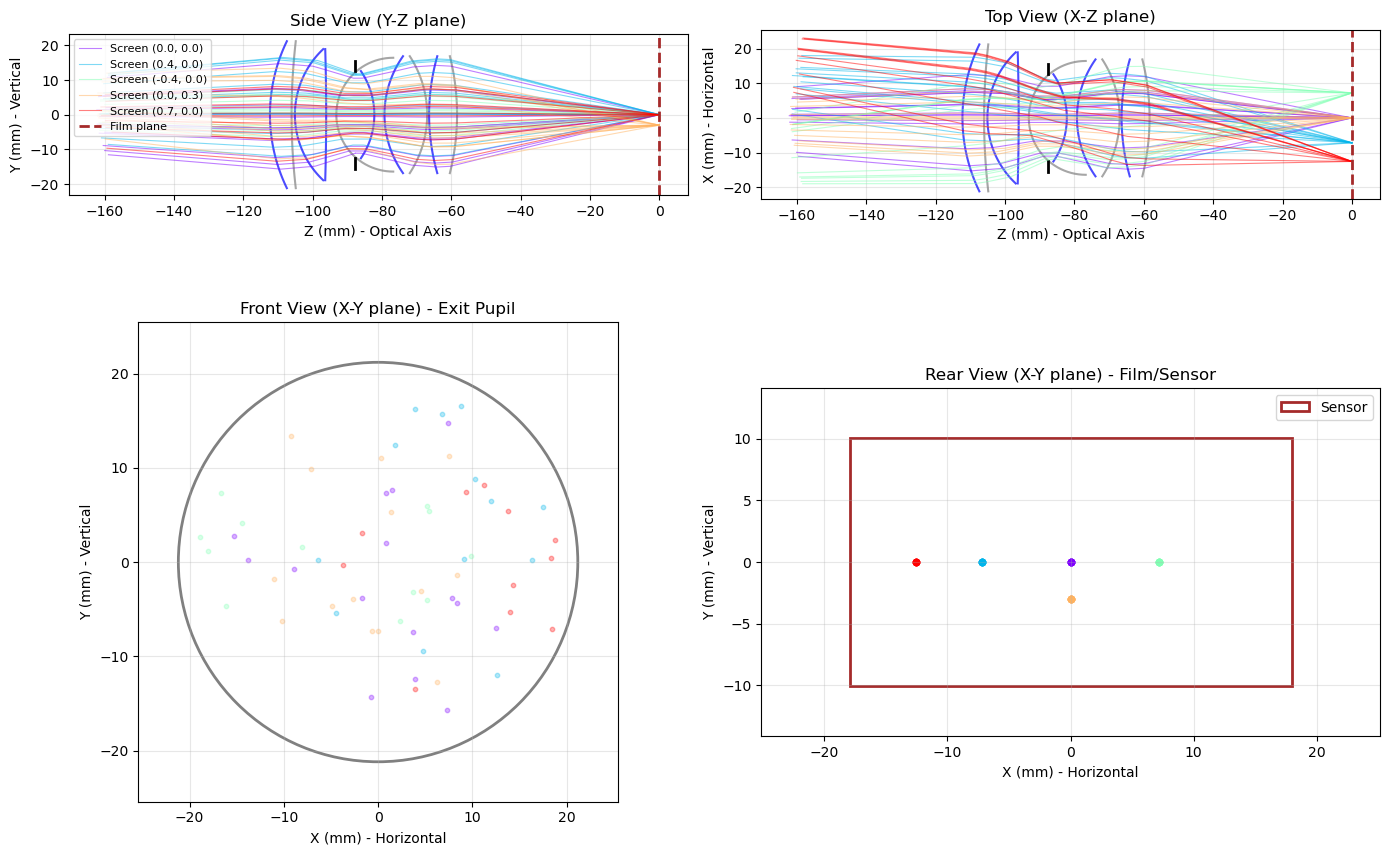

In [8]:
# === PLOT RAY PATHS ===

# Create lens elements
aperture_stop = 6  # f/4.0 for clearer visualization
focus_distance = 1.0
lens_elements = get_lens_elements(aperture_stop, focus_distance)

# Plot rays from different screen positions
fig = plot_ray_paths(
    lens_elements,
    num_rays=15,  # rays per position
    screen_positions=[
        (0.0, 0.0),    # center
        (0.4, 0.0),    # slight right
        (-0.4, 0.0),   # slight left
        (0.0, 0.3),    # slight up
        (0.7, 0.0),    # far right edge
    ],
    wavelength=0.0,  # monochrome
    seed=123
)

# Plots

In [95]:
output_folder_path = "C:\\Users\\ckobalt\\Documents\\MasterThesis\\picturesForThesis\\plots"

## Pinhole Plot

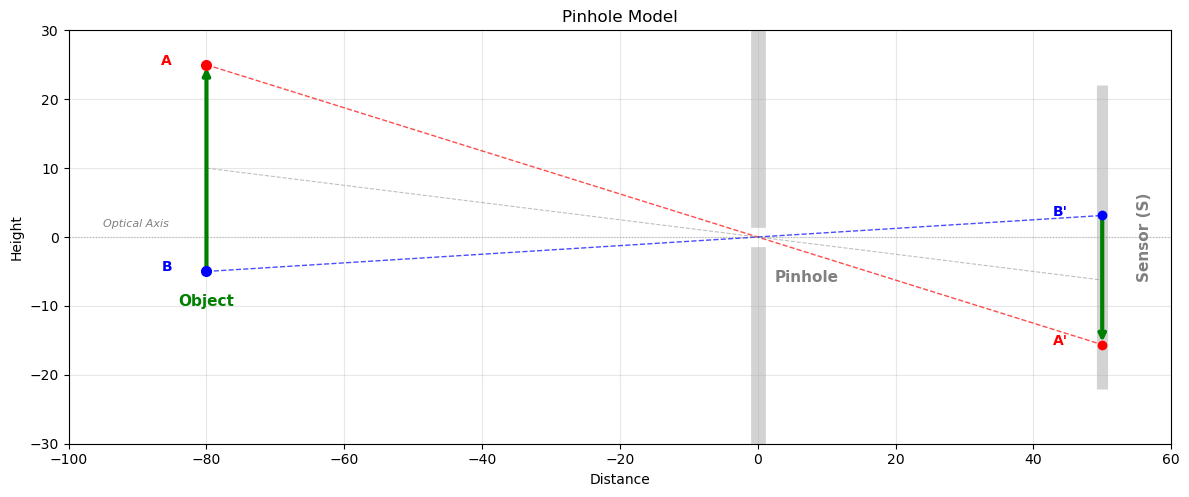

In [96]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def plot_pinhole_camera():
    fig, ax = plt.subplots(figsize=(12, 6))
    
    object_x, pinhole_x, sensor_x = -80, 0, 50
    object_height, object_base_y = 30, -5
    pinhole_radius, barrier_height = 1.5, 45
    
    arrow_tip_y = object_base_y + object_height
    arrow_base_y = object_base_y
    
    ax.annotate('', xy=(object_x, arrow_tip_y), xytext=(object_x, arrow_base_y),
                arrowprops=dict(arrowstyle='->', color='green', lw=3))
    ax.plot([object_x], [arrow_base_y], 'o', color='green', markersize=6)
    ax.text(object_x, arrow_base_y - 5, 'Object', ha='center', fontsize=11, fontweight='bold', color='green')
    
    ax.plot(object_x, arrow_tip_y, 'o', color='red', markersize=7, zorder=5)
    ax.plot(object_x, arrow_base_y, 'o', color='blue', markersize=7, zorder=5)
    ax.text(object_x - 5, arrow_tip_y, 'A', fontsize=10, ha='right', color='red', fontweight='bold')
    ax.text(object_x - 5, arrow_base_y, 'B', fontsize=10, ha='right', color='blue', fontweight='bold')
    
    ax.add_patch(patches.Rectangle((pinhole_x - 1, pinhole_radius), 2, barrier_height - pinhole_radius,
                                    linewidth=0.5, edgecolor='lightgray', facecolor='lightgray'))
    ax.add_patch(patches.Rectangle((pinhole_x - 1, -barrier_height), 2, barrier_height - pinhole_radius,
                                    linewidth=0.5, edgecolor='lightgray', facecolor='lightgray'))
    ax.text(pinhole_x + 2.5, -pinhole_radius - 5, 'Pinhole', ha='left', fontsize=11, fontweight='bold', color='gray')
    
    ax.plot([sensor_x, sensor_x], [-22, 22], color='lightgray', linewidth=8, solid_capstyle='butt', zorder=1)
    ax.text(sensor_x + 5, 0, 'Sensor (S)', fontsize=11, fontweight='bold', color='gray', va='center', rotation=90)
    
    magnification = abs(sensor_x - pinhole_x) / abs(object_x - pinhole_x)
    image_tip_y = -arrow_tip_y * magnification
    image_base_y = -arrow_base_y * magnification
    
    ax.plot([object_x, pinhole_x, sensor_x], [arrow_tip_y, 0, image_tip_y], 'r--', linewidth=1, alpha=0.7)
    ax.plot([object_x, pinhole_x, sensor_x], [arrow_base_y, 0, image_base_y], 'b--', linewidth=1, alpha=0.7)
    mid_y = (arrow_tip_y + arrow_base_y) / 2
    ax.plot([object_x, pinhole_x, sensor_x], [mid_y, 0, -mid_y * magnification], 'gray', linewidth=0.8, alpha=0.5, linestyle='--')
    
    ax.annotate('', xy=(sensor_x, image_tip_y), xytext=(sensor_x, image_base_y),
                arrowprops=dict(arrowstyle='->', color='green', lw=3), zorder=10)
    ax.plot([sensor_x], [image_base_y], 'o', color='green', markersize=5, zorder=10)
    ax.plot(sensor_x, image_tip_y, 'o', color='red', markersize=6, zorder=10)
    ax.plot(sensor_x, image_base_y, 'o', color='blue', markersize=6, zorder=10)
    ax.text(sensor_x - 5, image_tip_y, "A'", fontsize=10, ha='right', color='red', fontweight='bold')
    ax.text(sensor_x - 5, image_base_y, "B'", fontsize=10, ha='right', color='blue', fontweight='bold')
    
    ax.axhline(y=0, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.text(-95, 1.5, 'Optical Axis', fontsize=8, color='gray', style='italic')
    
    ax.set_title('Pinhole Model')
    ax.set_xlim(-100, 60)
    ax.set_ylim(-30, 30)
    ax.set_aspect('equal')
    ax.set_xlabel('Distance')
    ax.set_ylabel('Height')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(f"{output_folder_path}/pinhole_model.svg", format='svg', bbox_inches='tight')
    plt.show()
    return fig

fig = plot_pinhole_camera()

## Thin Lens Plot

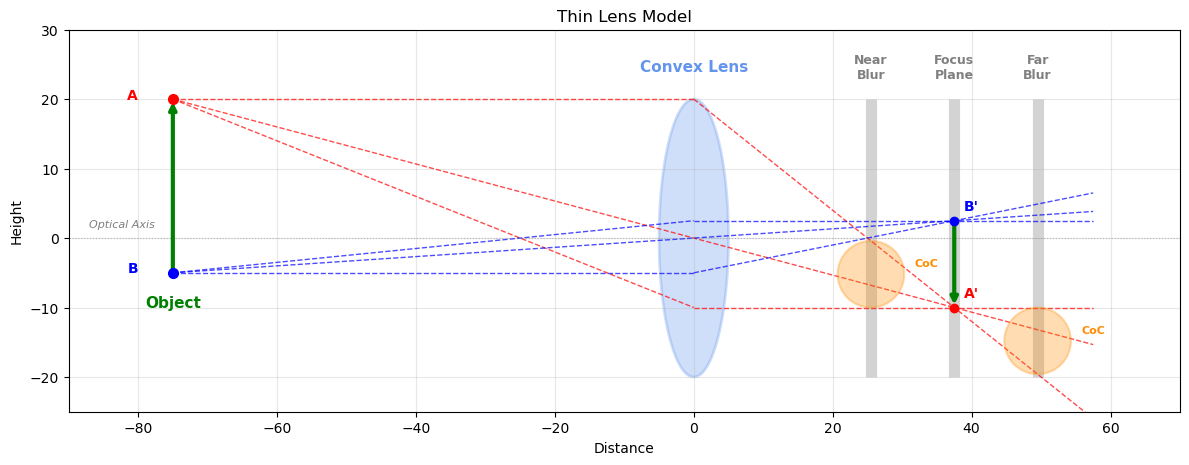

In [97]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def plot_thin_lens_camera():
    fig, ax = plt.subplots(figsize=(12, 6))
    
    lens_x, focal_length, lens_radius = 0, 25, 20
    object_x, object_height, object_base_y = -75, 25, -5
    
    do = abs(object_x - lens_x)
    di = (focal_length * do) / (do - focal_length)
    magnification = -di / do
    
    focused_sensor_x = lens_x + di
    near_sensor_x = focused_sensor_x - 12
    far_sensor_x = focused_sensor_x + 12
    
    arrow_tip_y = object_base_y + object_height
    arrow_base_y = object_base_y
    image_tip_y = arrow_tip_y * magnification
    image_base_y = arrow_base_y * magnification
    
    theta = np.linspace(-np.pi/2, np.pi/2, 100)
    lens_bulge = 5
    left_curve_x = lens_x - lens_bulge * np.cos(theta)
    right_curve_x = lens_x + lens_bulge * np.cos(theta)
    curve_y = lens_radius * np.sin(theta)
    ax.fill(np.concatenate([left_curve_x, right_curve_x[::-1]]),
            np.concatenate([curve_y, curve_y[::-1]]),
            color='cornflowerblue', alpha=0.3, edgecolor='cornflowerblue', linewidth=2)
    ax.text(lens_x, lens_radius + 4, 'Convex Lens', ha='center', fontsize=11, fontweight='bold', color='cornflowerblue')
    
    ax.annotate('', xy=(object_x, arrow_tip_y), xytext=(object_x, arrow_base_y),
                arrowprops=dict(arrowstyle='->', color='green', lw=3))
    ax.plot([object_x], [arrow_base_y], 'o', color='green', markersize=6)
    ax.text(object_x, arrow_base_y - 5, 'Object', ha='center', fontsize=11, fontweight='bold', color='green')
    ax.plot(object_x, arrow_tip_y, 'o', color='red', markersize=7, zorder=5)
    ax.plot(object_x, arrow_base_y, 'o', color='blue', markersize=7, zorder=5)
    ax.text(object_x - 5, arrow_tip_y, 'A', fontsize=10, ha='right', color='red', fontweight='bold')
    ax.text(object_x - 5, arrow_base_y, 'B', fontsize=10, ha='right', color='blue', fontweight='bold')
    
    def get_ray_heights(obj_y, x_pos):
        img_y = obj_y * magnification
        y1 = obj_y if x_pos <= lens_x else obj_y + (img_y - obj_y) * (x_pos - lens_x) / di
        y2 = obj_y * x_pos / object_x
        slope_to_F = -obj_y / (-focal_length - object_x)
        y_at_lens = obj_y + slope_to_F * (lens_x - object_x)
        y3 = obj_y + slope_to_F * (x_pos - object_x) if x_pos <= lens_x else y_at_lens
        return y1, y2, y3, y_at_lens
    
    x_end = far_sensor_x + 8
    
    for obj_y, color in [(arrow_tip_y, 'r'), (arrow_base_y, 'b')]:
        _, _, _, y_at_lens = get_ray_heights(obj_y, lens_x)
        y1_end, y2_end, _, _ = get_ray_heights(obj_y, x_end)
        
        ax.plot([object_x, lens_x], [obj_y, obj_y], f'{color}--', linewidth=1, alpha=0.7)
        ax.plot([lens_x, x_end], [obj_y, y1_end], f'{color}--', linewidth=1, alpha=0.7)
        ax.plot([object_x, x_end], [obj_y, y2_end], f'{color}--', linewidth=1, alpha=0.7)
        ax.plot([object_x, lens_x], [obj_y, y_at_lens], f'{color}--', linewidth=1, alpha=0.7)
        ax.plot([lens_x, x_end], [y_at_lens, y_at_lens], f'{color}--', linewidth=1, alpha=0.7)
    
    ax.plot(focused_sensor_x, image_tip_y, 'o', color='red', markersize=6, zorder=15)
    ax.plot(focused_sensor_x, image_base_y, 'o', color='blue', markersize=6, zorder=15)
    ax.text(focused_sensor_x + 3.5, image_tip_y + 1.5, "A'", fontsize=10, ha='right', color='red', fontweight='bold')
    ax.text(focused_sensor_x + 3.5, image_base_y + 1.5, "B'", fontsize=10, ha='right', color='blue', fontweight='bold')
    
    for sx, label in [(near_sensor_x, 'Near\nBlur'), (focused_sensor_x, 'Focus\nPlane'), (far_sensor_x, 'Far\nBlur')]:
        ax.plot([sx, sx], [-20, 20], color='lightgray', linewidth=8, solid_capstyle='butt', zorder=1)
        ax.text(sx, 23, label, ha='center', fontsize=9, color='gray', fontweight='bold')
        
        if abs(sx - focused_sensor_x) > 0.5:
            y1, y2, y3, _ = get_ray_heights(arrow_tip_y, sx)
            y_min, y_max = min(y1, y2, y3), max(y1, y2, y3)
            coc_radius = (y_max - y_min) / 2
            coc_center = (y_max + y_min) / 2
            ax.add_patch(patches.Circle((sx, coc_center), coc_radius, fill=True, facecolor='darkorange',
                                        alpha=0.3, edgecolor='darkorange', linewidth=1.5, zorder=10))
            ax.text(sx + coc_radius + 1.5, coc_center + 1.5, 'CoC', fontsize=8, color='darkorange', va='center', fontweight='bold')
    
    ax.annotate('', xy=(focused_sensor_x, image_tip_y), xytext=(focused_sensor_x, image_base_y),
                arrowprops=dict(arrowstyle='->', color='green', lw=3), zorder=10)
    ax.plot([focused_sensor_x], [image_base_y], 'o', color='green', markersize=5, zorder=10)
    
    ax.axhline(y=0, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.text(-87, 1.5, 'Optical Axis', fontsize=8, color='gray', style='italic')
    
    ax.set_title('Thin Lens Model')
    ax.set_xlim(-90, 70)
    ax.set_ylim(-25, 30)
    ax.set_aspect('equal')
    ax.set_xlabel('Distance')
    ax.set_ylabel('Height')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(f"{output_folder_path}/thin_lens_model.svg", format='svg', bbox_inches='tight')
    plt.show()
    return fig

fig = plot_thin_lens_camera()

## Chromatic Aberration Plot

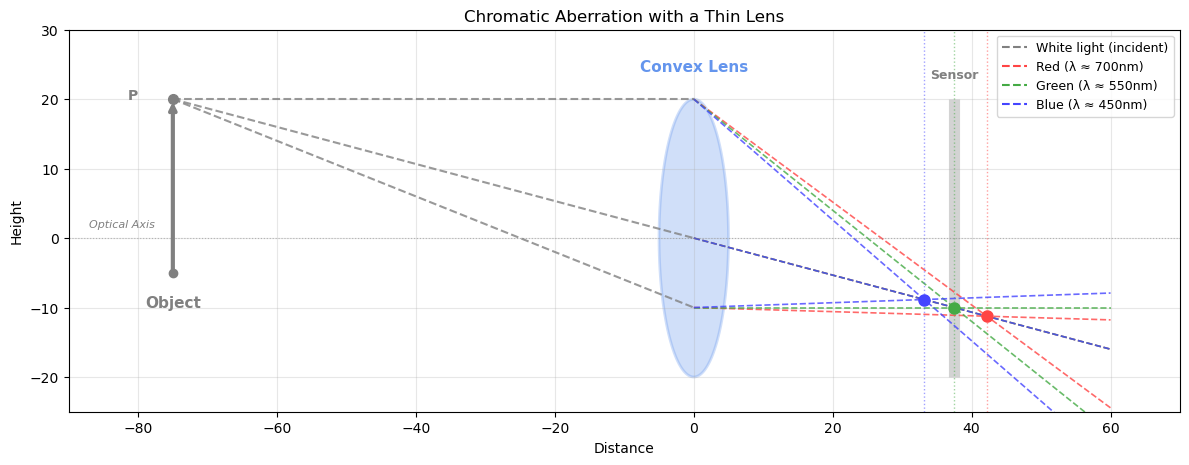

In [101]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def plot_chromatic_aberration():
    fig, ax = plt.subplots(figsize=(12, 6))
    
    lens_x, lens_radius = 0, 20
    object_x, object_height, object_base_y = -75, 25, -5
    focal_red, focal_green, focal_blue = 27, 25, 23
    
    arrow_tip_y = object_base_y + object_height
    do = abs(object_x - lens_x)
    x_end = 60
    
    theta = np.linspace(-np.pi/2, np.pi/2, 100)
    lens_bulge = 5
    left_curve_x = lens_x - lens_bulge * np.cos(theta)
    right_curve_x = lens_x + lens_bulge * np.cos(theta)
    curve_y = lens_radius * np.sin(theta)
    ax.fill(np.concatenate([left_curve_x, right_curve_x[::-1]]),
            np.concatenate([curve_y, curve_y[::-1]]),
            color='cornflowerblue', alpha=0.3, edgecolor='cornflowerblue', linewidth=2)
    ax.text(lens_x, lens_radius + 4, 'Convex Lens', ha='center', fontsize=11, fontweight='bold', color='cornflowerblue')
    
    ax.annotate('', xy=(object_x, arrow_tip_y), xytext=(object_x, object_base_y),
                arrowprops=dict(arrowstyle='->', color='gray', lw=3))
    ax.plot([object_x], [object_base_y], 'o', color='gray', markersize=6)
    ax.text(object_x, object_base_y - 5, 'Object', ha='center', fontsize=11, fontweight='bold', color='gray')
    ax.plot(object_x, arrow_tip_y, 'o', color='gray', markersize=7, zorder=5)
    ax.text(object_x - 5, arrow_tip_y, 'P', fontsize=10, ha='right', color='gray', fontweight='bold')
    
    wavelengths = [('red', focal_red, '#ff4444'), ('green', focal_green, '#44aa44'), ('blue', focal_blue, '#4444ff')]
    
    ray1_lens_y = arrow_tip_y
    ray2_lens_y = 0
    slope_to_F_green = -arrow_tip_y / (-focal_green - object_x)
    ray3_lens_y = arrow_tip_y + slope_to_F_green * (lens_x - object_x)
    
    ax.plot([object_x, lens_x], [arrow_tip_y, ray1_lens_y], color='gray', linestyle='--', linewidth=1.5, alpha=0.8)
    ax.plot([object_x, lens_x], [arrow_tip_y, ray2_lens_y], color='gray', linestyle='--', linewidth=1.5, alpha=0.8)
    ax.plot([object_x, lens_x], [arrow_tip_y, ray3_lens_y], color='gray', linestyle='--', linewidth=1.5, alpha=0.8)
    
    for name, f, color in wavelengths:
        di = (f * do) / (do - f)
        img_y = arrow_tip_y * (-di / do)
        
        slope1 = (img_y - ray1_lens_y) / di
        ax.plot([lens_x, x_end], [ray1_lens_y, ray1_lens_y + slope1 * (x_end - lens_x)], color=color, linestyle='--', linewidth=1.2, alpha=0.8)
        
        slope2 = (ray2_lens_y - arrow_tip_y) / (lens_x - object_x)
        ax.plot([lens_x, x_end], [ray2_lens_y, ray2_lens_y + slope2 * (x_end - lens_x)], color=color, linestyle='--', linewidth=1.2, alpha=0.8)
        
        slope3 = (img_y - ray3_lens_y) / di
        ax.plot([lens_x, x_end], [ray3_lens_y, ray3_lens_y + slope3 * (x_end - lens_x)], color=color, linestyle='--', linewidth=1.2, alpha=0.8)
        
        ax.plot(lens_x + di, img_y, 'o', color=color, markersize=8, zorder=15)
        ax.axvline(x=lens_x + di, color=color, linestyle=':', linewidth=1, alpha=0.5)
    
    di_green = (focal_green * do) / (do - focal_green)
    ax.plot([lens_x + di_green, lens_x + di_green], [-20, 20], color='lightgray', linewidth=8, solid_capstyle='butt', zorder=1)
    ax.text(lens_x + di_green, 23, 'Sensor', ha='center', fontsize=9, color='gray', fontweight='bold')
    
    legend_elements = [
        plt.Line2D([0], [0], color='gray', linestyle='--', label='White light (incident)'),
        plt.Line2D([0], [0], color='#ff4444', linestyle='--', label='Red (λ ≈ 700nm)'),
        plt.Line2D([0], [0], color='#44aa44', linestyle='--', label='Green (λ ≈ 550nm)'),
        plt.Line2D([0], [0], color='#4444ff', linestyle='--', label='Blue (λ ≈ 450nm)'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
    
    ax.axhline(y=0, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.text(-87, 1.5, 'Optical Axis', fontsize=8, color='gray', style='italic')
    
    ax.set_title('Chromatic Aberration with a Thin Lens')
    ax.set_xlim(-90, 70)
    ax.set_ylim(-25, 30)
    ax.set_aspect('equal')
    ax.set_xlabel('Distance')
    ax.set_ylabel('Height')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(f"{output_folder_path}/chromatic_aberration.svg", format='svg', bbox_inches='tight')
    plt.show()
    return fig

fig = plot_chromatic_aberration()